# HDD, BOA and Tape carbon accounting

This is the **calculation and plotting notebook**. It reads measurements exported by
`01_run_BOA_and_CodeCarbon.ipynb`; it does not execute BOA, start CodeCarbon or duplicate measured values.

The single plot distinguishes:

1. BOA regional electricity scenarios for actual U.K. execution and counterfactual Switzerland, Sweden and
   Germany electricity mixes;
2. HDD and Tape carbon-cost curves;
3. carbon-cost crossover points, which are not the paper-defined BEP.

The paper-defined metric remains

$$
\mathrm{BEP}=\frac{E_{\mathrm{optim}}}{e_{\mathrm{orig}}-e_{\mathrm{opt}}}.
$$

BOA embodied carbon remains excluded. HDD and Tape inputs and their stated boundaries are unchanged.

## 1. Shared result folder and scenario controls

Notebook 03 requires the files created by notebook 01:

- `boa_metrics.json`;
- `boa_scaling_measurements.csv`;
- `concatenated_file_results.csv`.

The actual CodeCarbon run is fixed to `GBR`. Regional comparisons do not pretend that the experiment was rerun
elsewhere: they multiply the same measured stage energy by the 2023 country-average electricity carbon intensity
shipped in CodeCarbon's official `global_energy_mix.json`.

`PRIMARY_REGION_ISO = "GBR"` controls the component lines and the annotated HDD/Tape crossovers. All four BOA
regional totals are drawn on the same plot.

In [22]:
from pathlib import Path
import json
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RETENTION_YEARS = 5.0
EXPECTED_DECOMPRESSIONS = 1

# 6,000,000 MB = 6 TB
MAX_DATA_MB = 6_000_000.0
NUMBER_OF_POINTS = 12001

INCLUDE_FIRST_STORAGE_UNIT = True
PRIMARY_REGION_ISO = "GBR"
TAPE_OPERATIONAL_MODE = "ral_complete_service"
PROJECT_FOLDER_NAME = "BOA_carbon_project"

UNCOMPRESSED_READ_GCO2E_PER_MB = None
COMPRESSED_READ_GCO2E_PER_MB_EXCL_DECOMPRESSION = None

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive") / PROJECT_FOLDER_NAME
else:
    local_project = Path.cwd() / PROJECT_FOLDER_NAME
    PROJECT_ROOT = local_project if local_project.exists() else Path.cwd()

RESULTS_DIR = PROJECT_ROOT / "results"
BOA_METRICS_PATH = RESULTS_DIR / "boa_metrics.json"
BOA_SCALING_PATH = RESULTS_DIR / "boa_scaling_measurements.csv"
BOA_CONCAT_PATH = RESULTS_DIR / "concatenated_file_results.csv"

required_paths = [
    BOA_METRICS_PATH,
    BOA_SCALING_PATH,
    BOA_CONCAT_PATH,
]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    formatted = "\n".join(f"  - {path}" for path in missing_paths)
    raise FileNotFoundError(
        "Notebook 03 requires outputs from notebook 01. "
        "Run notebook 01 through its scaling section first.\n"
        f"Missing:\n{formatted}"
    )

if RETENTION_YEARS <= 0:
    raise ValueError("RETENTION_YEARS must be positive.")
if EXPECTED_DECOMPRESSIONS < 0:
    raise ValueError("EXPECTED_DECOMPRESSIONS must be non-negative.")
if TAPE_OPERATIONAL_MODE not in {"ral_complete_service", "lto8_same_source"}:
    raise ValueError("Unknown TAPE_OPERATIONAL_MODE.")

print("Shared project root:", PROJECT_ROOT)
print("Reading BOA results from:", RESULTS_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shared project root: /content/drive/MyDrive/BOA_carbon_project
Reading BOA results from: /content/drive/MyDrive/BOA_carbon_project/results


## 2. Numerical inputs and literature boundaries

Storage inputs are unchanged:

- Seagate Exos X18: 18 TB capacity, 5.3 W average idle power and proportional non-use allocation
  `1.50 gCO2e/GB`.
- Tape: whole 12 TB LTO-8 cartridge proxy plus the selected operational factor.
- The HDD operational scenario continues to use the U.K. factor derived from Packer & Skipsey, preserving the
  existing storage calculation.

BOA regional scenarios use CodeCarbon's official 2023 country-average factors:

- United Kingdom (`GBR`): `237.589 gCO2e/kWh`;
- Switzerland (`CHE`): `34.843 gCO2e/kWh`;
- Sweden (`SWE`): `40.695 gCO2e/kWh`;
- Germany (`DEU`): `380.950 gCO2e/kWh`.

These factors change only the conversion from measured BOA energy to CO₂e. They do not change measured runtime
or energy.

In [23]:
# ---------- U.K. carbon intensity derived from Packer & Skipsey ----------
# UK carbon intensity derived from Packer & Skipsey:
# 31,500 kWh/year -> 6,551 kgCO2e/year
UK_GRID_GCO2E_PER_KWH = (6551.0 / 31_500.0) * 1000.0


# CodeCarbon official 2023 country-average carbon intensities.
# Source:
# https://github.com/mlco2/codecarbon/blob/master/codecarbon/data/private_infra/global_energy_mix.json
BOA_REGION_INTENSITY_GCO2E_PER_KWH = {
    "GBR": 237.589,
    "CHE": 34.843,
    "SWE": 40.695,
    "DEU": 380.950,
}

BOA_REGION_NAMES = {
    "GBR": "United Kingdom (actual run)",
    "CHE": "Switzerland scenario",
    "SWE": "Sweden scenario",
    "DEU": "Germany scenario",
}

if PRIMARY_REGION_ISO not in BOA_REGION_INTENSITY_GCO2E_PER_KWH:
    raise ValueError(f"Unknown PRIMARY_REGION_ISO: {PRIMARY_REGION_ISO}")


# ============================================================
# HDD
# ============================================================

# Representative 18 TB capacity block.
HDD_CAPACITY_GB = 18_000.0

# Seagate Exos X18 product-LCA non-use stages:
# 2.28 kgCO2e/(TB year) * (1 - 0.868 use-phase share) * 5 years
# = 1.5048 kgCO2e/TB = 1.5048 gCO2e/GB, rounded to the meeting value 1.50.
HDD_EMBODIED_GCO2E_PER_GB = 1.50

# Seagate Exos X18 average idle power. Operational carbon is charged to
# an integer number of installed drives, as requested in the meeting.
HDD_IDLE_POWER_W = 5.30


# ============================================================
# Tape
# ============================================================

# The 13.72 kgCO2e cartridge assessment is for LTO-8, 12 TB native capacity.
TAPE_CAPACITY_GB = 12_000.0

# Packer & Skipsey, Table 2
TAPE_TOTAL_LIFECYCLE_KGCO2E_PER_CARTRIDGE = 13.72
TAPE_USE_PHASE_KGCO2E_PER_CARTRIDGE = 5.70

# Remove use phase because operational carbon is calculated separately
TAPE_NON_USE_KGCO2E_PER_CARTRIDGE = (
    TAPE_TOTAL_LIFECYCLE_KGCO2E_PER_CARTRIDGE
    - TAPE_USE_PHASE_KGCO2E_PER_CARTRIDGE
)

# Same-source LTO-8 allocated drive energy:
# 5.70 kg / (12,000 GB * 10 years) = 0.0475 g/(GB year).
TAPE_LTO8_SAME_SOURCE_OPERATIONAL_GCO2E_PER_GB_YEAR = 0.0475

# Packer & Skipsey complete RAL tape service:
# 148 kg/(usable PB year) = 0.148 g/(GB year).
TAPE_RAL_COMPLETE_SERVICE_OPERATIONAL_GCO2E_PER_GB_YEAR = 0.148

TAPE_OPERATIONAL_FACTORS = {
    "ral_complete_service": TAPE_RAL_COMPLETE_SERVICE_OPERATIONAL_GCO2E_PER_GB_YEAR,
    "lto8_same_source": TAPE_LTO8_SAME_SOURCE_OPERATIONAL_GCO2E_PER_GB_YEAR,
}

TAPE_NON_USE_GCO2E_PER_GB = (
    TAPE_NON_USE_KGCO2E_PER_CARTRIDGE * 1000.0 / TAPE_CAPACITY_GB
)

# BOA values are loaded from notebook 01 in the next cell.

source_table = pd.DataFrame(
    [
        ["HDD embodied", "1.50 gCO2e/GB", "Seagate Exos X18 non-use stages", "proportional attribution"],
        ["HDD operational", "5.30 W / 18 TB drive", "Seagate Exos X18 report", "integer powered drives"],
        ["Tape non-use proxy", "8.02 kg per 12 TB LTO-8 cartridge", "Fujifilm/BJC via Packer & Skipsey", "whole cartridge; at least one"],
        ["Tape operational (selected)", f"{TAPE_OPERATIONAL_FACTORS[TAPE_OPERATIONAL_MODE]:.4f} gCO2e/(GB year)", TAPE_OPERATIONAL_MODE, "the only Tape operational value used in the plot"],
        ["Tape operational (alternative)", "0.0475 or 0.148 gCO2e/(GB year)", "same-source LTO-8 or complete RAL service", "not combined; unused mode is not plotted"],
        ["BOA operational", "three CodeCarbon stages", "01_run_BOA_and_CodeCarbon.ipynb", "no hardware embodied allocation"],
    ],
    columns=["component", "value", "source", "allocation"],
)
print(source_table.to_string(index=False))
print(f"\nHDD U.K. grid factor: {UK_GRID_GCO2E_PER_KWH:.3f} gCO2e/kWh")
print("BOA regional factors:", BOA_REGION_INTENSITY_GCO2E_PER_KWH)
print(f"Selected Tape operational mode: {TAPE_OPERATIONAL_MODE}")
print(f"LTO-8 non-use proxy: {TAPE_NON_USE_GCO2E_PER_GB:.6f} gCO2e/GB")

# Same-source identity: 0.668333 + 10 * 0.0475 = 1.143333 gCO2e/GB.
assert math.isclose(
    TAPE_NON_USE_GCO2E_PER_GB
    + 10.0 * TAPE_LTO8_SAME_SOURCE_OPERATIONAL_GCO2E_PER_GB_YEAR,
    TAPE_TOTAL_LIFECYCLE_KGCO2E_PER_CARTRIDGE * 1000.0 / TAPE_CAPACITY_GB,
    rel_tol=1e-12,
)

                     component                             value                                    source                                       allocation
                  HDD embodied                     1.50 gCO2e/GB           Seagate Exos X18 non-use stages                         proportional attribution
               HDD operational              5.30 W / 18 TB drive                   Seagate Exos X18 report                           integer powered drives
            Tape non-use proxy 8.02 kg per 12 TB LTO-8 cartridge         Fujifilm/BJC via Packer & Skipsey                    whole cartridge; at least one
   Tape operational (selected)            0.1480 gCO2e/(GB year)                      ral_complete_service the only Tape operational value used in the plot
Tape operational (alternative)   0.0475 or 0.148 gCO2e/(GB year) same-source LTO-8 or complete RAL service         not combined; unused mode is not plotted
               BOA operational           three CodeCarbon stages

## 3. BOA scaling fitted from notebook 01 measurements

For each stage \(s\), notebook 01 supplies measured energy \(E_{s,i}\) at input volumes \(D_i\). Notebook 03 fits
a through-origin energy slope:

$$
\hat\beta^{(E)}_s
=\frac{\sum_i D_iE_{s,i}}{\sum_iD_i^2},
\qquad
\hat E_s(D)=\hat\beta^{(E)}_sD.
$$

For region \(r\) with carbon intensity \(I_r\),

$$
\hat C_{s,r}(D)=\hat E_s(D)I_r.
$$

Training, compression and decompression are fitted separately. The measured regionalized points are also drawn
for the primary U.K. line, so deviations from linearity remain visible.

In [24]:
with BOA_METRICS_PATH.open("r", encoding="utf-8") as handle:
    BOA_METRICS = json.load(handle)

BOA_SCALING = pd.read_csv(BOA_SCALING_PATH)
BOA_CONCAT_RESULTS = pd.read_csv(BOA_CONCAT_PATH)

required_metric_keys = {
    "input_MB",
    "training_runtime_s",
    "training_energy_kWh",
    "training_emissions_kgCO2eq",
    "compression_runtime_s",
    "compression_energy_kWh",
    "compression_emissions_kgCO2eq",
    "decompression_runtime_s",
    "decompression_energy_kWh",
    "decompression_emissions_kgCO2eq",
    "model_MB",
}
missing_metric_keys = sorted(required_metric_keys - set(BOA_METRICS))
if missing_metric_keys:
    raise KeyError(f"boa_metrics.json is missing keys: {missing_metric_keys}")

required_scaling_columns = {
    "factor",
    "input_MB",
    "stage",
    "runtime_s",
    "energy_kWh",
    "emissions_kgCO2eq",
    "measurement_policy",
}
missing_scaling_columns = sorted(
    required_scaling_columns - set(BOA_SCALING.columns)
)
if missing_scaling_columns:
    raise KeyError(
        "boa_scaling_measurements.csv is missing columns: "
        f"{missing_scaling_columns}"
    )

MEASURED_FILE_MB = float(BOA_METRICS["input_MB"])


def through_origin_slope(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y >= 0)
    x = x[valid]
    y = y[valid]
    if len(x) < 2:
        raise ValueError(
            "At least two finite measurements are required for a scaling fit."
        )
    denominator = float(np.dot(x, x))
    if denominator <= 0:
        raise ValueError("Cannot fit a through-origin slope.")
    return float(np.dot(x, y) / denominator)


STAGES = ("training", "compression", "decompression")
stage_energy_slopes_kWh_per_MB = {}
fit_rows = []

for stage in STAGES:
    stage_frame = (
        BOA_SCALING.loc[BOA_SCALING["stage"] == stage]
        .sort_values("input_MB")
        .copy()
    )
    stage_frame = stage_frame.loc[
        np.isfinite(stage_frame["energy_kWh"])
        & np.isfinite(stage_frame["input_MB"])
    ]
    if stage_frame["input_MB"].nunique() < 2:
        raise ValueError(
            f"Notebook 01 must measure {stage} at at least two input sizes."
        )
    stage_energy_slopes_kWh_per_MB[stage] = through_origin_slope(
        stage_frame["input_MB"],
        stage_frame["energy_kWh"],
    )
    fit_rows.extend(stage_frame.to_dict(orient="records"))

BOA_MEASURED_POINTS = pd.DataFrame(fit_rows)


def region_stage_slope_g_per_MB(stage, region_iso):
    if region_iso not in BOA_REGION_INTENSITY_GCO2E_PER_KWH:
        raise ValueError(f"Unknown BOA region: {region_iso}")
    return (
        stage_energy_slopes_kWh_per_MB[stage]
        * BOA_REGION_INTENSITY_GCO2E_PER_KWH[region_iso]
    )


baseline_reported_intensity_rows = []
for stage in STAGES:
    energy = float(BOA_METRICS[f"{stage}_energy_kWh"])
    emissions_g = (
        float(BOA_METRICS[f"{stage}_emissions_kgCO2eq"]) * 1000.0
    )
    implied_intensity = emissions_g / energy
    baseline_reported_intensity_rows.append(
        {
            "stage": stage,
            "baseline_input_MB": MEASURED_FILE_MB,
            "measured_energy_kWh": energy,
            "reported_CodeCarbon_gCO2e": emissions_g,
            "implied_gCO2e_per_kWh": implied_intensity,
            "fitted_energy_kWh_per_MB": (
                stage_energy_slopes_kWh_per_MB[stage]
            ),
        }
    )

boa_stage_table = pd.DataFrame(baseline_reported_intensity_rows)
print("Loaded:", BOA_METRICS_PATH)
print("Loaded:", BOA_SCALING_PATH)
print(boa_stage_table.to_string(index=False, float_format=lambda x: f"{x:.9g}"))
print("\nRegional BOA factors:")
print(
    pd.DataFrame(
        [
            {
                "region_iso": code,
                "region": BOA_REGION_NAMES[code],
                "gCO2e_per_kWh": intensity,
            }
            for code, intensity
            in BOA_REGION_INTENSITY_GCO2E_PER_KWH.items()
        ]
    ).to_string(index=False)
)

Loaded: /content/drive/MyDrive/BOA_carbon_project/results/boa_metrics.json
Loaded: /content/drive/MyDrive/BOA_carbon_project/results/boa_scaling_measurements.csv
        stage  baseline_input_MB  measured_energy_kWh  reported_CodeCarbon_gCO2e  implied_gCO2e_per_kWh  fitted_energy_kWh_per_MB
     training              49.92        0.00924186295                 2.19576498                237.589            2.41996576e-05
  compression              49.92       0.000750485671                 0.17830714                237.589            1.41396727e-05
decompression              49.92       0.000771627613                0.183330233                237.589            1.51049717e-05

Regional BOA factors:
region_iso                      region  gCO2e_per_kWh
       GBR United Kingdom (actual run)        237.589
       CHE        Switzerland scenario         34.843
       SWE             Sweden scenario         40.695
       DEU            Germany scenario        380.950


## 4. Compression-ratio measurements from notebook 01

The table below is loaded from `concatenated_file_results.csv`; no ratio is copied into notebook 03. It retains
the original 2× point as well as approximately 1, 2, 5 and 10 GB inputs.

`ratio_excl_model` measures payload compression. `ratio_incl_one_shared_model` includes one shared model.
Repeated content remains an initial scaling test, not evidence that the same ratio holds for different files.

In [25]:
MODEL_MB = float(BOA_METRICS["model_MB"])
concat_results = BOA_CONCAT_RESULTS.copy()
concat_results["copies"] = concat_results["factor"].astype(int)
concat_results = concat_results.sort_values("copies").reset_index(drop=True)

required_concat_columns = {
    "copies",
    "input_MB",
    "ratio_excl_model",
    "ratio_incl_one_shared_model",
    "roundtrip_ok",
}
missing_concat_columns = sorted(
    required_concat_columns - set(concat_results.columns)
)
if missing_concat_columns:
    raise KeyError(
        "concatenated_file_results.csv is missing columns: "
        f"{missing_concat_columns}"
    )

first = concat_results.iloc[0]
last = concat_results.iloc[-1]
payload_relative_change_pct = (
    last["ratio_excl_model"] / first["ratio_excl_model"] - 1.0
) * 100.0
effective_relative_change_pct = (
    last["ratio_incl_one_shared_model"]
    / first["ratio_incl_one_shared_model"]
    - 1.0
) * 100.0

print(
    concat_results[
        [
            "copies",
            "input_MB",
            "ratio_excl_model",
            "ratio_incl_one_shared_model",
            "roundtrip_ok",
        ]
    ].to_string(index=False, float_format=lambda x: f"{x:.9f}")
)
print(
    f"\nFirst-to-largest payload-ratio change: "
    f"{payload_relative_change_pct:.6f}%"
)
print(
    f"First-to-largest effective-ratio change: "
    f"{effective_relative_change_pct:.3f}%"
)

 copies      input_MB  ratio_excl_model  ratio_incl_one_shared_model  roundtrip_ok
      1  49.920000000       3.724705467                  3.542232322          True
      2  99.840000000       3.724711164                  3.631183354          True
      4 199.680000000       3.724717070                  3.677358428          True
      6 299.520000000       3.724718668                  3.693011832          True
      8 399.360000000       3.724719328                  3.700888477          True

First-to-largest payload-ratio change: 0.000372%
First-to-largest effective-ratio change: 4.479%


## 5. Carbon equations

Let \(D\) be the original data volume in GB.

HDD embodied allocation:

$$
C_{\mathrm{HDD,emb}}(D)=1.50D.
$$

The physical integer drive count is

$$
N_{\mathrm{HDD}}(D)=\left\lceil\frac{D}{18{,}000}\right\rceil.
$$

Using `int(D/capacity)` would under-provision whenever \(D\) is not an exact multiple, so `ceil` is the correct implementation of the meeting's integer-drive assumption. For the installed-unit plot, `max(1, ...)` represents the right-hand limit for any positive data volume: at least one unit is installed. The point drawn at \(D=0\) is a plotting convention for that installed-unit scenario, not a claim that zero data physically requires storage.

HDD operational:

$$
C_{\mathrm{HDD,op}}=
N_{\mathrm{HDD}}(D)\frac{5.3}{1000}(24)(365.25)T\,CI.
$$

Tape uses 12 TB LTO-8 cartridges. Its integer cartridge count and fixed non-use/embodied proxy are

$$
N_{\mathrm{Tape}}(D)=\max\left(1,\left\lceil\frac{D}{12{,}000}\right\rceil\right),
$$

$$
C_{\mathrm{Tape,nonuse}}(D)=8.02\,N_{\mathrm{Tape}}(D)\;\mathrm{kgCO2e},
$$

so the plotted Tape total does not start at zero. With the selected RAL complete-service operational factor,

$$
C_{\mathrm{Tape,op}}(D)=D(0.148)T\;\mathrm{gCO2e}.
$$

The fixed cartridge proxy and the RAL operational factor have different source boundaries; their sum is therefore labelled a mixed-boundary estimate, not a complete Tape LCA.


In [26]:
def integer_units(data_GB, capacity_GB, include_first_at_zero=True):
    data = np.asarray(data_GB, dtype=float)
    if np.any(data < 0):
        raise ValueError("Data volume must be non-negative.")
    count = np.ceil(data / capacity_GB).astype(int)
    if include_first_at_zero:
        count = np.maximum(count, 1)
    return count


def hdd_carbon_g(data_MB, retention_years=RETENTION_YEARS):
    data_MB = np.asarray(data_MB, dtype=float)
    data_GB = data_MB / 1000.0

    # Physical integer number of 18 TB capacity blocks
    n_hdd = integer_units(
        data_GB,
        HDD_CAPACITY_GB,
        INCLUDE_FIRST_STORAGE_UNIT,
    )

    # Proportional Exos X18 non-use-stage allocation:
    # 1.50 gCO2e for every GB of project data
    embodied_g = (
        data_GB
        * HDD_EMBODIED_GCO2E_PER_GB
    )

    # Integer-drive idle-power scenario requested in the meeting.
    operational_g = (
        n_hdd
        * HDD_IDLE_POWER_W / 1000.0
        * 24.0 * 365.25
        * retention_years
        * UK_GRID_GCO2E_PER_KWH
    )

    total_g = embodied_g + operational_g

    return embodied_g, operational_g, total_g, n_hdd


def tape_carbon_g(
    data_MB,
    retention_years=RETENTION_YEARS,
    operational_mode=None,
):
    data_MB = np.asarray(data_MB, dtype=float)
    data_GB = data_MB / 1000.0
    if operational_mode is None:
        operational_mode = TAPE_OPERATIONAL_MODE
    if operational_mode not in TAPE_OPERATIONAL_FACTORS:
        raise ValueError(f"Unknown Tape operational mode: {operational_mode}")

    n_tape = integer_units(
        data_GB,
        TAPE_CAPACITY_GB,
        INCLUDE_FIRST_STORAGE_UNIT,
    )

    non_use_g = (
        n_tape
        * TAPE_NON_USE_KGCO2E_PER_CARTRIDGE
        * 1000.0
    )

    operational_rate = TAPE_OPERATIONAL_FACTORS[operational_mode]
    operational_g = data_GB * operational_rate * retention_years

    total_g = non_use_g + operational_g

    return non_use_g, operational_g, total_g, n_tape


def boa_carbon_g(
    data_MB,
    decompressions=EXPECTED_DECOMPRESSIONS,
    region_iso=PRIMARY_REGION_ISO,
):
    data_MB = np.asarray(data_MB, dtype=float)
    if np.any(data_MB < 0):
        raise ValueError("Data volume must be non-negative.")
    training = (
        region_stage_slope_g_per_MB("training", region_iso)
        * data_MB
    )
    compression = (
        region_stage_slope_g_per_MB("compression", region_iso)
        * data_MB
    )
    decompression = (
        region_stage_slope_g_per_MB("decompression", region_iso)
        * data_MB
        * decompressions
    )
    inference = compression + decompression
    total = training + inference
    return training, compression, decompression, inference, total

## 6. Single carbon plot

The plot contains:

- four BOA totals based on the same measured energy but different regional electricity factors;
- U.K. BOA training and inference components separately;
- HDD and Tape totals and their existing components;
- U.K. BOA–Tape and BOA–HDD crossover annotations.

Only the U.K. scenario is an actual CodeCarbon-location match. Switzerland, Sweden and Germany are
counterfactual electricity-mix sensitivities.

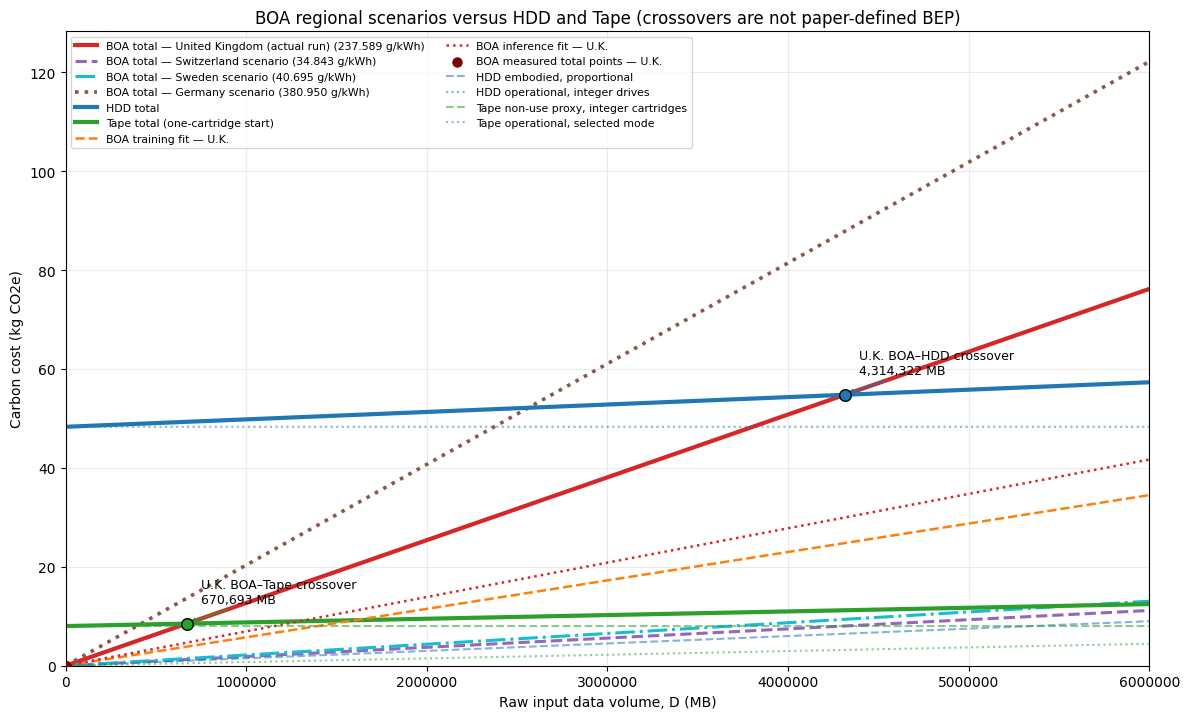

U.K. BOA–Tape crossover: 670,693.152 MB
U.K. BOA–HDD crossover:  4,314,321.668 MB


In [31]:
def first_continuous_crossover(x, lower_at_zero, other):
    difference = np.asarray(lower_at_zero) - np.asarray(other)
    candidates = np.where(
        (difference[:-1] <= 0) & (difference[1:] > 0)
    )[0]
    if len(candidates) == 0:
        return math.nan
    i = int(candidates[0])
    x0, x1 = x[i], x[i + 1]
    y0, y1 = difference[i], difference[i + 1]
    return float(x0 - y0 * (x1 - x0) / (y1 - y0))


data_MB = np.linspace(0.0, MAX_DATA_MB, NUMBER_OF_POINTS)
hdd_emb, hdd_op, hdd_total, hdd_count = hdd_carbon_g(data_MB)
tape_emb, tape_op, tape_total, tape_count = tape_carbon_g(data_MB)

assert np.all(hdd_count == 1)
assert np.all(tape_count == 1)
assert math.isclose(float(tape_total[0]), 8020.0, abs_tol=1e-9)

region_curves = {}
for region_iso in BOA_REGION_INTENSITY_GCO2E_PER_KWH:
    region_curves[region_iso] = boa_carbon_g(
        data_MB,
        region_iso=region_iso,
    )

(
    boa_training,
    boa_compression,
    boa_decompression,
    boa_inference,
    boa_total,
) = region_curves[PRIMARY_REGION_ISO]

boa_tape_crossover_MB = first_continuous_crossover(
    data_MB, boa_total, tape_total
)
boa_hdd_crossover_MB = first_continuous_crossover(
    data_MB, boa_total, hdd_total
)

fig, ax = plt.subplots(figsize=(12.0, 7.3))

region_styles = {
    "GBR": {"color": "#d62728", "ls": "-", "lw": 3.0},
    "CHE": {"color": "#9467bd", "ls": "--", "lw": 2.2},
    "SWE": {"color": "#17becf", "ls": "-.", "lw": 2.2},
    "DEU": {"color": "#8c564b", "ls": ":", "lw": 2.6},
}

for region_iso, components in region_curves.items():
    ax.plot(
        data_MB,
        components[-1] / 1000.0,
        label=(
            f"BOA total — {BOA_REGION_NAMES[region_iso]} "
            f"({BOA_REGION_INTENSITY_GCO2E_PER_KWH[region_iso]:.3f} g/kWh)"
        ),
        **region_styles[region_iso],
    )

ax.plot(
    data_MB,
    hdd_total / 1000.0,
    color="#1f77b4",
    lw=3.0,
    label="HDD total",
)
ax.plot(
    data_MB,
    tape_total / 1000.0,
    color="#2ca02c",
    lw=3.0,
    label="Tape total (one-cartridge start)",
)

ax.plot(
    data_MB,
    boa_training / 1000.0,
    color="#ff7f0e",
    ls="--",
    lw=1.8,
    label="BOA training fit — U.K.",
)
ax.plot(
    data_MB,
    boa_inference / 1000.0,
    color="#d62728",
    ls=":",
    lw=1.8,
    label="BOA inference fit — U.K.",
)

stage_points = {
    stage: (
        BOA_MEASURED_POINTS.loc[
            BOA_MEASURED_POINTS["stage"] == stage
        ][["input_MB", "energy_kWh"]]
        .rename(columns={"energy_kWh": stage})
    )
    for stage in STAGES
}
measured_total_points = (
    stage_points["training"]
    .merge(stage_points["compression"], on="input_MB")
    .merge(stage_points["decompression"], on="input_MB")
)
measured_total_energy = (
    measured_total_points["training"]
    + measured_total_points["compression"]
    + EXPECTED_DECOMPRESSIONS
    * measured_total_points["decompression"]
)
measured_total_g = (
    measured_total_energy
    * BOA_REGION_INTENSITY_GCO2E_PER_KWH[PRIMARY_REGION_ISO]
)
ax.scatter(
    measured_total_points["input_MB"],
    measured_total_g / 1000.0,
    color="#7f0000",
    s=42,
    zorder=7,
    label="BOA measured total points — U.K.",
)

ax.plot(
    data_MB,
    hdd_emb / 1000.0,
    color="#1f77b4",
    ls="--",
    alpha=0.55,
    label="HDD embodied, proportional",
)
ax.plot(
    data_MB,
    hdd_op / 1000.0,
    color="#1f77b4",
    ls=":",
    alpha=0.55,
    label="HDD operational, integer drives",
)
ax.plot(
    data_MB,
    tape_emb / 1000.0,
    color="#2ca02c",
    ls="--",
    alpha=0.55,
    label="Tape non-use proxy, integer cartridges",
)
ax.plot(
    data_MB,
    tape_op / 1000.0,
    color="#2ca02c",
    ls=":",
    alpha=0.55,
    label="Tape operational, selected mode",
)

for x_cross, label, color in [
    (boa_tape_crossover_MB, "U.K. BOA–Tape crossover", "#2ca02c"),
    (boa_hdd_crossover_MB, "U.K. BOA–HDD crossover", "#1f77b4"),
]:
    if math.isfinite(x_cross):
        y_cross = (
            float(
                boa_carbon_g(
                    x_cross,
                    region_iso=PRIMARY_REGION_ISO,
                )[-1]
            )
            / 1000.0
        )
        ax.scatter(
            [x_cross],
            [y_cross],
            s=70,
            color=color,
            edgecolor="black",
            zorder=8,
        )
        ax.annotate(
            f"{label}\n{x_cross:,.0f} MB",
            (x_cross, y_cross),
            xytext=(10, 15),
            textcoords="offset points",
            fontsize=9,
            arrowprops={"arrowstyle": "->", "color": color},
        )

ax.set_xlabel("Raw input data volume, D (MB)")
ax.set_ylabel("Carbon cost (kg CO2e)")
ax.set_title(
    "BOA regional scenarios versus HDD and Tape "
    "(crossovers are not paper-defined BEP)"
)
ax.grid(True, alpha=0.25)
ax.set_xlim(0, MAX_DATA_MB)
ax.set_ylim(bottom=0)
ax.ticklabel_format(axis="x", style="plain")
ax.legend(loc="upper left", ncol=2, fontsize=7.8)
fig.tight_layout()
plt.show()

print(f"U.K. BOA–Tape crossover: {boa_tape_crossover_MB:,.3f} MB")
print(f"U.K. BOA–HDD crossover:  {boa_hdd_crossover_MB:,.3f} MB")

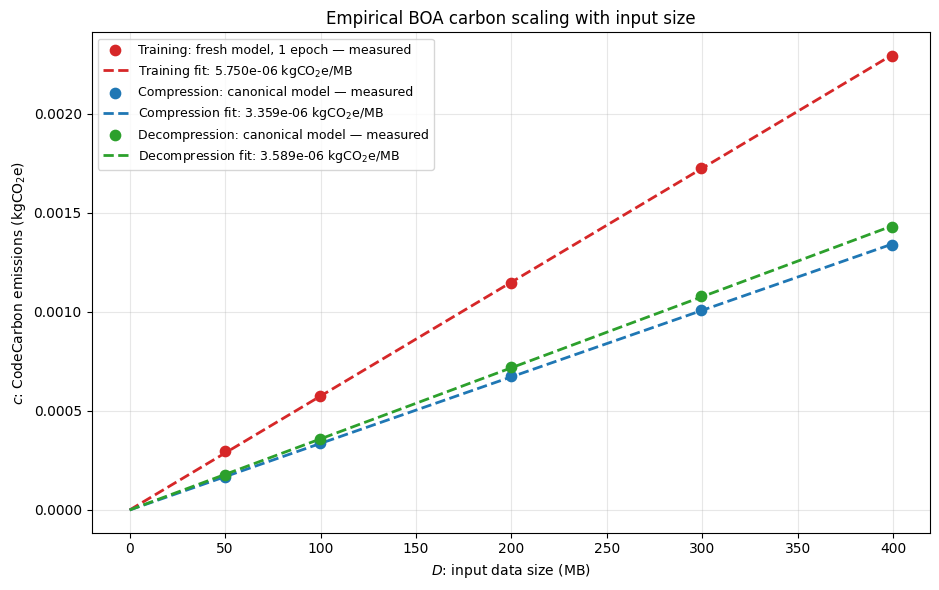

In [28]:
# ============================================================
# Empirical CodeCarbon scaling: D (input MB) versus c (kgCO2e)
# ============================================================

stage_styles = {
    "training": {
        "color": "#d62728",
        "label": "Training: fresh model, 1 epoch",
    },
    "compression": {
        "color": "#1f77b4",
        "label": "Compression: canonical model",
    },
    "decompression": {
        "color": "#2ca02c",
        "label": "Decompression: canonical model",
    },
}

fig, ax = plt.subplots(figsize=(9.5, 6.0))

for stage in ("training", "compression", "decompression"):
    measured = (
        BOA_SCALING.loc[
            BOA_SCALING["stage"] == stage,
            ["input_MB", "emissions_kgCO2eq"],
        ]
        .dropna()
        .sort_values("input_MB")
    )

    D_MB = measured["input_MB"].to_numpy(dtype=float)
    c_kgCO2e = measured["emissions_kgCO2eq"].to_numpy(dtype=float)

    if len(D_MB) < 2:
        raise ValueError(
            f"{stage} needs at least two measured input sizes to plot scaling."
        )

    # Through-origin least-squares fit: c(D) = beta * D
    beta_kgCO2e_per_MB = (
        np.dot(D_MB, c_kgCO2e) / np.dot(D_MB, D_MB)
    )
    D_fit = np.linspace(0.0, D_MB.max(), 200)
    c_fit = beta_kgCO2e_per_MB * D_fit

    style = stage_styles[stage]
    ax.scatter(
        D_MB,
        c_kgCO2e,
        s=55,
        color=style["color"],
        zorder=3,
        label=f"{style['label']} — measured",
    )
    ax.plot(
        D_fit,
        c_fit,
        color=style["color"],
        linewidth=2,
        linestyle="--",
        label=(
            f"{stage.title()} fit: "
            f"{beta_kgCO2e_per_MB:.3e} kgCO$_2$e/MB"
        ),
    )

ax.set_xlabel(r"$D$: input data size (MB)")
ax.set_ylabel(r"$c$: CodeCarbon emissions (kgCO$_2$e)")
ax.set_title("Empirical BOA carbon scaling with input size")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 7. Component audit at the primary U.K. crossovers

The audit retains the original HDD, Tape and BOA boundary breakdown. BOA values use the U.K. electricity factor;
other regional scenarios affect only BOA operational carbon.

In [29]:
def scalar_components(data_mb):
    h_emb, h_op, h_total, h_n = hdd_carbon_g(data_mb)
    t_emb, t_op, t_total, t_n = tape_carbon_g(data_mb)
    b_train, b_comp, b_decomp, b_inf, b_total = boa_carbon_g(data_mb)
    return {
        "HDD": {
            "boundary": "Exos X18 proportional embodied + integer-drive idle power",
            "embodied_g": float(h_emb),
            "operational_g": float(h_op),
            "total_g": float(h_total),
            "integer_units": int(h_n),
        },
        "Tape": {
            "boundary": "LTO-8 non-use proxy + selected Tape operational mode",
            "embodied_g": float(t_emb),
            "operational_g": float(t_op),
            "total_g": float(t_total),
            "integer_units": int(t_n),
        },
        "BOA": {
            "boundary": "Measured BOA energy × U.K. CodeCarbon 2023 factor; no embodied allocation",
            "embodied_g": 0.0,
            "training_g": float(b_train),
            "compression_g": float(b_comp),
            "decompression_g": float(b_decomp),
            "inference_g": float(b_inf),
            "total_g": float(b_total),
        },
    }


audit_rows = []
for crossover_name, x_cross in [
    ("BOA-Tape", boa_tape_crossover_MB),
    ("BOA-HDD", boa_hdd_crossover_MB),
]:
    components = scalar_components(x_cross)
    for option, values in components.items():
        audit_rows.append(
            {
                "crossover": crossover_name,
                "data_MB": x_cross,
                "option": option,
                **values,
            }
        )

crossover_audit = pd.DataFrame(audit_rows)
print(crossover_audit.fillna("").to_string(index=False, float_format=lambda x: f"{x:.6f}"))
assert (crossover_audit.loc[crossover_audit["option"] == "BOA", "embodied_g"] == 0).all()

crossover        data_MB option                                                                  boundary  embodied_g operational_g      total_g integer_units   training_g compression_g decompression_g  inference_g
 BOA-Tape 3915697.636273    HDD                 Exos X18 proportional embodied + integer-drive idle power 5873.546454  48310.817429 54184.363883      1.000000                                                        
 BOA-Tape 3915697.636273   Tape                      LTO-8 non-use proxy + selected Tape operational mode 8020.000000   2897.616251 10917.616251      1.000000                                                        
 BOA-Tape 3915697.636273    BOA Measured BOA energy × U.K. CodeCarbon 2023 factor; no embodied allocation    0.000000               49720.660359               22513.587263  13154.514794    14052.558302 27207.073097
  BOA-HDD                   HDD                 Exos X18 proportional embodied + integer-drive idle power              48310.817429         

/tmp/ipykernel_471/256712364.py:5: RuntimeWarning: invalid value encountered in cast
  count = np.ceil(data / capacity_GB).astype(int)


## 8. Paper-defined BEP

The supplied definition is

$$
\mathrm{BEP}=\frac{E_{\mathrm{optim}}}{e_{\mathrm{orig}}-e_{\mathrm{opt}}},
$$

where \(E_{\mathrm{optim}}\) is a one-time optimization cost and \(e_{\mathrm{orig}}\), \(e_{\mathrm{opt}}\) are per-execution costs.

For BOA, a defensible read-based mapping is:

- \(E_{\mathrm{optim}}\): training + initial compression;
- \(e_{\mathrm{orig}}\): one future read of the uncompressed data;
- \(e_{\mathrm{opt}}\): one future read of the compressed data + decompression.

Notebook 01 measured decompression, but it did **not** separately measure the uncompressed-read and compressed-read carbon costs. Therefore the BEP must remain **not computable** with the current measurements. If \(e_{\mathrm{orig}}\le e_{\mathrm{opt}}\), the paper defines BEP as undefined.


In [30]:
def bep_executions(E_optim, e_orig, e_opt):
    values = np.asarray([E_optim, e_orig, e_opt], dtype=float)
    if not np.all(np.isfinite(values)):
        return math.nan
    denominator = e_orig - e_opt
    if denominator <= 0:
        return math.nan
    return E_optim / denominator


def boa_read_bep(
    data_MB,
    uncompressed_read_g_per_MB=UNCOMPRESSED_READ_GCO2E_PER_MB,
    compressed_read_g_per_MB=COMPRESSED_READ_GCO2E_PER_MB_EXCL_DECOMPRESSION,
):
    train, comp, decomp, _, _ = boa_carbon_g(
        data_MB, decompressions=1
    )
    if uncompressed_read_g_per_MB is None or compressed_read_g_per_MB is None:
        return {
            "data_MB": float(data_MB),
            "E_optim_gCO2e": float(train + comp),
            "e_orig_gCO2e_per_read": math.nan,
            "e_opt_gCO2e_per_read": math.nan,
            "BEP_reads": math.nan,
            "status": "not computable: read-carbon measurements are missing",
        }
    e_orig = uncompressed_read_g_per_MB * data_MB
    e_opt = compressed_read_g_per_MB * data_MB + float(decomp)
    bep = bep_executions(float(train + comp), e_orig, e_opt)
    status = (
        "defined"
        if math.isfinite(bep)
        else "undefined: optimized read is not lower-carbon"
    )
    return {
        "data_MB": float(data_MB),
        "E_optim_gCO2e": float(train + comp),
        "e_orig_gCO2e_per_read": float(e_orig),
        "e_opt_gCO2e_per_read": float(e_opt),
        "BEP_reads": bep,
        "status": status,
    }


bep_result = boa_read_bep(MEASURED_FILE_MB)
print(pd.DataFrame([bep_result]).to_string(index=False))

 data_MB  E_optim_gCO2e  e_orig_gCO2e_per_read  e_opt_gCO2e_per_read  BEP_reads                                               status
   49.92       0.454721                    NaN                   NaN        NaN not computable: read-carbon measurements are missing


## 9. Assumptions and limitations

1. Notebook 01 measures; notebook 03 calculates and plots. No BOA value is hard-coded or re-measured here.
2. Training uses a fresh model with the same epochs at each successfully completed size. Inference reuses the
   canonical model. These are different policies and remain explicitly labelled.
3. The first scaling inputs are repeated copies. Different-file tests are still required.
4. The 10 GB decompression may exceed Colab memory because the current BOA API returns the complete restored
   byte string.
5. The actual run is U.K.-located. Switzerland, Sweden and Germany are electricity-mix counterfactuals computed
   from identical measured energy.
6. Country-average CodeCarbon factors are static 2023 values, not time- or datacentre-specific marginal factors.
7. One future decompression is assumed.
8. HDD embodied proportionality is attributional and does not prove proportional avoided procurement.
9. HDD operational is discrete; a partial disk does not consume partial idle power.
10. Tape retains a fixed installed-unit start and a mixed boundary.
11. Storage replacement is not modelled in the plotted five-year window.
12. True BEP still requires uncompressed-read and compressed-read measurements.
13. The BOA curves remain compute-only; a later net-system study must include compressed-output storage.

## References

1. Packer, A. and Skipsey, S. C., *Carbon costs of storage: a U.K. perspective*, EPJ Web of Conferences 337, 01157 (2025), Tables 2 and 5. https://doi.org/10.1051/epjconf/202533701157
2. Johns, B., *Improving Information Technology Sustainability with Modern Tape Storage*, Brad Johns Consulting and Fujifilm (2021), LTO-8 12 TB cartridge lifecycle assessment. https://asset.fujifilm.com/www/de/files/2023-10/97ddc3473883421cef1fb820d236dfa2/Improving_IT_Sustainability_with_Tape_BJC_0.pdf
3. Seagate, *Exos X18 18TB Product Sustainability Report* (2023). https://www.seagate.com/content/dam/seagate/assets/esg/planet/product-sustainability/images/exos-x18-sustainability-report/files/Exos-X18-18TB-Sustainability-Report-2023.pdf
4. Tannu, S. and Nair, P. J., *The Dirty Secret of SSDs: Embodied Carbon*, arXiv:2207.10793 / ACM SIGENERGY EIR (2023). https://arxiv.org/abs/2207.10793
5. Wadenstein, M. and Vanderbauwhede, W., *Life Cycle Analysis for Emissions of Scientific Computing Centres*, arXiv:2506.14365. https://arxiv.org/abs/2506.14365
6. Byrne, T., *Evaluating the Performance and Power Efficiency of Ceph Storage Configurations*, CHEP 2026. https://indico.cern.ch/event/1471803/contributions/6966744/
7. User-supplied BEP definition excerpt. https://hal.science/hal-05227453v1/document

8. CodeCarbon, `global_energy_mix.json`, 2023 country-average electricity carbon intensities. https://github.com/mlco2/codecarbon/blob/master/codecarbon/data/private_infra/global_energy_mix.json